In [72]:
import cv2
import numpy as np
import os
from sklearn.metrics import precision_recall_curve, auc, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt
from tqdm import tqdm

# ---------------------------
# CONFIGURATION
# ---------------------------
KITTI_PATH = "data_odometry_gray/dataset/sequences/00/image_0"  # e.g. ./dataset/sequences/00/image_2/
N_IMAGES = 300          # Limit number of images for demo/testing
ORB_FEATURES = 2100     # Number of ORB keypoints per image
RESIZE_TO = (640, 192)  # Resize for consistent feature scale

# ---------------------------
# 1. Load KITTI Images
# ---------------------------
def load_images(path, n_images):
    """Load grayscale KITTI images"""
    images = []
    filenames = sorted(os.listdir(path))[:n_images]
    for f in filenames:
        img = cv2.imread(os.path.join(path, f))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        images.append(gray)
    return images, filenames

In [58]:
# ---------------------------
# 2. Image Preprocessing
# ---------------------------
def preprocess_image(img):
    """
    Perform standard preprocessing:
    1. Resize to a fixed size
    2. Histogram equalization to normalize lighting
    3. Gaussian blur to reduce noise
    """
    # Resize
    img_resized = cv2.resize(img, RESIZE_TO)
    # Histogram equalization
    img_eq = cv2.equalizeHist(img_resized)
    # Denoise slightly
    img_blur = cv2.GaussianBlur(img_eq, (3, 3), 0)
    return img_blur

def preprocess_images(images):
    preprocessed = []
    for img in tqdm(images, desc="Preprocessing images"):
        preprocessed.append(preprocess_image(img))
    return preprocessed

In [59]:
# ---------------------------
# 3. Feature Extraction (ORB)
# ---------------------------
def extract_features(images):
    orb = cv2.ORB_create(nfeatures=ORB_FEATURES)
    descriptors = []
    keypoints_all = []
    for img in tqdm(images, desc="Extracting features"):
        kp, des = orb.detectAndCompute(img, None)
        keypoints_all.append(kp)
        descriptors.append(des)
    return keypoints_all, descriptors

# ---------------------------
# 4. Feature Matching (Brute Force)
# ---------------------------
def match_features(des1, des2, ratio=0.87):
    if des1 is None or des2 is None:
        return []
    bf = cv2.BFMatcher(cv2.NORM_HAMMING)
    matches = bf.knnMatch(des1, des2, k=2)
    good = [m for m, n in matches if m.distance < ratio * n.distance]
    return good

In [60]:
# ---------------------------
# 5. Geometric Verification
# ---------------------------
def geometric_verification(kp1, kp2, matches, reproj_thresh=5.0):
    if len(matches) < 4:
        return 0
    pts1 = np.float32([kp1[m.queryIdx].pt for m in matches])
    pts2 = np.float32([kp2[m.trainIdx].pt for m in matches])
    _, mask = cv2.findHomography(pts1, pts2, cv2.RANSAC, reproj_thresh)
    return int(mask.sum()) if mask is not None else 0

In [61]:
# ---------------------------
# 6. Compute Similarity Matrix
# ---------------------------
def compute_similarity(descriptors, keypoints):
    n = len(descriptors)
    similarity = np.zeros((n, n))
    for i in tqdm(range(n), desc="Computing similarity"):
        for j in range(i + 1, n):
            matches = match_features(descriptors[i], descriptors[j])
            kp1, kp2 = keypoints[i], keypoints[j]
            geom_inliers = geometric_verification(kp1, kp2, matches)
            raw_count = len(matches)
            max_kp = min(len(kp1), len(kp2)) if kp1 and kp2 else 1
            similarity[i,j] = similarity[j,i] = (0.38 * geom_inliers + 0.62 * raw_count) / max_kp
    return similarity

In [62]:
# ---------------------------
# 7. Detect Revisits (Simple Threshold)
# ---------------------------
def detect_revisits(similarity, threshold):
    n = len(similarity)
    predicted = []
    actual = []
    for i in range(n):
        for j in range(i + 20, n):  # skip nearby frames to avoid trivial matches
            sim_score = similarity[i, j]
            is_revisit = 1 if sim_score > threshold else 0
            predicted.append(is_revisit)
            # For demonstration: frames < 3 apart = same location
            actual.append(1 if abs(i - j) < 3 else 0)
    return np.array(actual), np.array(predicted)


In [63]:
# ---------------------------
# 8. Evaluation: Precision, Recall, AUC
# ---------------------------
def evaluate(similarity):
    """
    Evaluate similarity matrix using synthetic loop closures.
    A "revisit" occurs when frame j is roughly 150 frames after i (simulated loop closure).
    """
    y_true, y_scores = [], []
    n = len(similarity)
    LOOP_OFFSET = 20  # synthetic revisit offset
    TOLERANCE = 4      # how close in frames to count as same place
    SKIP_NEARBY = 20   # ignore temporally close pairs

    for i in range(n):
        for j in range(i + SKIP_NEARBY, n):
            y_scores.append(similarity[i, j])
            # True positive if the pair corresponds to a synthetic loop closure
            is_revisit = 1 if abs((j - i) - LOOP_OFFSET) < TOLERANCE else 0
            y_true.append(is_revisit)

    y_true = np.array(y_true)
    y_scores = np.array(y_scores)

    # Print some sanity info
    print(f"\nTotal pairs: {len(y_true)}")
    print(f"Positives: {np.sum(y_true)} Negatives: {len(y_true) - np.sum(y_true)}")
    print(f"Score min/max/mean: {y_scores.min():.4f} {y_scores.max():.4f} {y_scores.mean():.4f}")

    if np.sum(y_true) == 0:
        print("⚠️ No positive pairs found! Adjust LOOP_OFFSET or TOLERANCE.")
        return np.array([]), np.array([]), 0.0

    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    auc_score = auc(recall, precision)
    return precision, recall, auc_score

📂 Loading images...
🧼 Preprocessing images...


Preprocessing images: 100%|████████████████████████████████████████████████████████| 300/300 [00:00<00:00, 2907.80it/s]


🔍 Extracting features...


Extracting features: 100%|██████████████████████████████████████████████████████████| 300/300 [00:02<00:00, 136.80it/s]


🔗 Computing similarity matrix...


Computing similarity: 100%|██████████████████████████████████████████████████████████| 300/300 [29:27<00:00,  5.89s/it]


📊 Evaluating performance...

Total pairs: 39340
Positives: 1114 Negatives: 38226
Score min/max/mean: 0.0376 0.1686 0.0617

✅ AUC (Precision-Recall): 33.66%


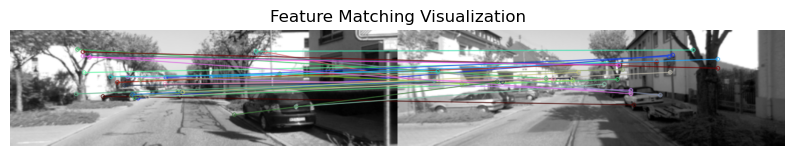

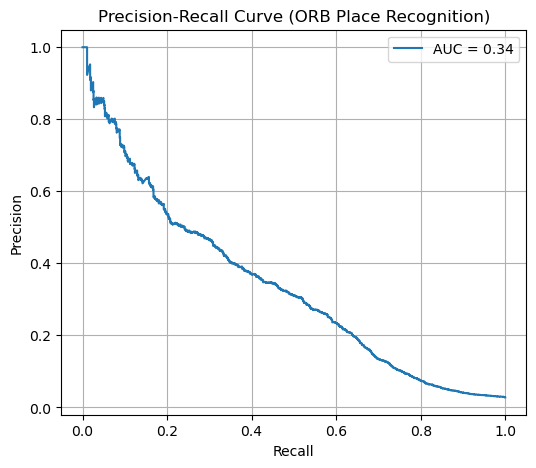

In [64]:
# ---------------------------
# 9. Visualization
# ---------------------------
def visualize_matches(img1, img2, kp1, kp2, matches):
    matched_img = cv2.drawMatches(img1, kp1, img2, kp2, matches[:30], None, flags=2)
    plt.figure(figsize=(10, 5))
    plt.imshow(cv2.cvtColor(matched_img, cv2.COLOR_BGR2RGB))
    plt.title("Feature Matching Visualization")
    plt.axis("off")
    plt.show()

# ---------------------------
# MAIN PIPELINE
# ---------------------------
if __name__ == "__main__":
    print("📂 Loading images...")
    images, names = load_images(KITTI_PATH, N_IMAGES)

    print("🧼 Preprocessing images...")
    preprocessed_images = preprocess_images(images)

    print("🔍 Extracting features...")
    keypoints_all, descriptors = extract_features(preprocessed_images)

    print("🔗 Computing similarity matrix...")
    similarity = compute_similarity(descriptors, keypoints_all)

    print("📊 Evaluating performance...")
    precision, recall, auc_score = evaluate(similarity)
    print(f"\n✅ AUC (Precision-Recall): {auc_score * 100:.2f}%")

    # Example visualization
    idx1, idx2 = 0, 50
    matches = match_features(descriptors[idx1], descriptors[idx2])
    visualize_matches(preprocessed_images[idx1], preprocessed_images[idx2],
                      keypoints_all[idx1], keypoints_all[idx2], matches)

    # Plot Precision-Recall curve
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AUC = {auc_score:.2f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve (ORB Place Recognition)")
    plt.legend()
    plt.grid(True)
    plt.show()

Confusion Matrix:
[[24625  4995]
 [ 4786  4934]]


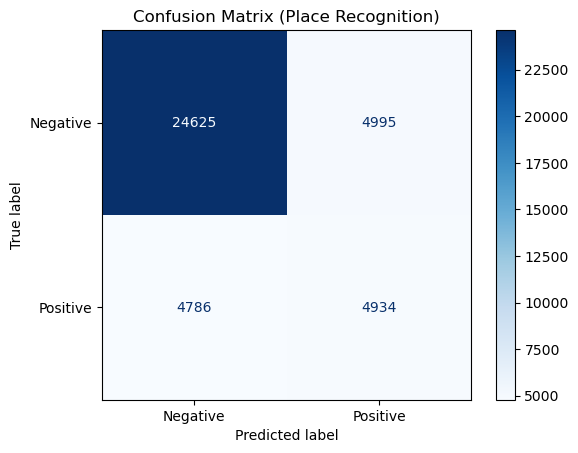

In [73]:
threshold = 0.005  #
y_pred = (y_scores > threshold).astype(int)
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Place Recognition)")
plt.show()
